In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from read_file_folder_X import read_file_folder_X
from read_file_folder_cVertices import read_file_folder_cVertices
from read_file_folder_cell_bin_categories import read_file_folder_cell_bin_categories
from read_file_folder import read_file_folder

In [ ]:
import numpy as np
from read_file_folder_X import read_file_folder_X
from read_file_folder_cVertices import read_file_folder_cVertices
from read_file_folder_vel import read_file_folder_vel
from read_file_folder_v_vel import read_file_folder_v_vel
from read_file_folder_cell_bin_categories import read_file_folder_cell_bin_categories
from read_file_folder import read_file_folder
import os
cwd = os.getcwd()

# NOTE: These helper functions are not in the provided MATLAB files
# You'll need to implement them separately
# from helper_functions import get_rotation_angle, tensor_coordinate_transformation, get_Q_angle


def get_rotation_angle(x, y):
    """Helper function to calculate rotation angle"""
    return np.arctan2(y, x)


def tensor_coordinate_transformation(tensor, theta):
    """Helper function to perform tensor coordinate transformation"""
    rotation_matrix = np.array([[np.cos(theta), np.sin(theta)],
                                 [-np.sin(theta), np.cos(theta)]])
    return rotation_matrix @ tensor @ rotation_matrix.T


def get_Q_angle(Q):
    """Helper function to calculate Q tensor angle"""
    # Calculate angle of Q tensor (typically the orientation angle)
    return 0.5 * np.arctan2(2 * Q[0, 1], Q[0, 0] - Q[1, 1])

def read_v_xy_file_full(filepath):
    """
    Read all columns from v_xy_*.dat file
    
    Returns:
    --------
    data : numpy array
        Full data array with all columns
    """
    data = np.loadtxt(filepath, comments='#')
    return data


kP=0.01
P0=4
time=1000
rho_0=1
gammaW = 1
folder_path=(
            f'/mnt/users/wangg/VertexModelChiralWetEdges/output/'
            f'out_Nx_60_kA_0.5_kP_0.01_P0_4_disorder_0.02_tMAX_1000_dw_50_di_50_ca1_0.03_ca2_0_iC_0_iP_0.25_iS_1_iT_10_dynamics_2_gammaW_1_zetaW_32_tT_0')

Lb=1
r_a=15



"""
Calculate the Kirkwood stress of all cells at given time

Parameters:
-----------
folder_path : str
    Path to the data folder
kP : float
    Perimeter stiffness
P0 : float
    Target perimeter
time : int
    Time step
force_type : int
    1: cell force; 2: cell elastic force; 3: cell perimeter force;
    4: cell area force; 5: cell chiral force
rho_0 : float
    Density parameter
Lb : float
    Bin size parameter (multiplier for bin width)

Returns:
--------
Multiple numpy arrays containing stress components for total, active, and passive cells

NOTE: Q_theoretical is only defined for force_type = cell perimeter force (3)
"""

rho_0 = 1

# Read data files
c_v_xpos_list = read_file_folder_X(folder_path, f'X_{time}.dat')
c_v_ypos_list = read_file_folder_X(folder_path, f'Y_{time}.dat')
cVertices = read_file_folder_cVertices(folder_path, f'c_vertices_{time}.dat')
Nc = len(cVertices)

cForces = read_file_folder_cVertices(folder_path, f'cell_force_{time}.dat') # total chiral+elastic force on vertices

vNeighbors = read_v_xy_file_full(os.path.join(folder_path, f'v_neighbors_{time}.dat'))[:, 1].astype(int) # vertex neighbor list (excluding vertex ID column)

cActivity = read_file_folder_cell_bin_categories(folder_path, f'c_activity_{time}.dat')
_, perioY = read_file_folder(folder_path, f'perio_{time}.dat')

cbins = np.arange(0, perioY + Lb * perioY / np.sqrt(Nc), Lb * perioY / np.sqrt(Nc))
nbins = len(cbins)

data = read_v_xy_file_full(os.path.join(folder_path, f'v_xy_{time}.dat'))

v_velx = data [:,4] # x component of v_vel
v_vely = data [:,5] # y component of v_vel
v_fx = data [:,6] # x component of v_f
v_fy = data [:,7] # y component of v_f


v_viscous_dissipation_x = v_fx - gammaW * v_velx
v_viscous_dissipation_y = v_fy - gammaW * v_vely


Nv = len(v_velx)


print('cVertices', cVertices)

# Calculate cell centers
xpos_center_active = []
ypos_center_active = []
xpos_center = np.zeros(Nc)
ypos_center = np.zeros(Nc)

for cid in range(Nc):
    cVertices_row = cVertices[cid]
    c_v_xpos_list_current = c_v_xpos_list[cid]
    c_v_ypos_list_current = c_v_ypos_list[cid]
    Nv_current = int(cVertices_row[1])

    # Calculate cell center
    vid_count = 0

    for vid in cVertices_row[2:2 + Nv_current]:
        xpos_center[cid] += c_v_xpos_list_current[vid_count]
        ypos_center[cid] += c_v_ypos_list_current[vid_count]
        vid_count += 1

    xpos_center[cid] /= Nv_current
    ypos_center[cid] /= Nv_current

    if cActivity[cid] == 1:
        xpos_center_active.append(xpos_center[cid])
        ypos_center_active.append(ypos_center[cid])

chiral_cell_center = np.zeros(2)
chiral_cell_center[0] = np.sum(xpos_center_active) / len(xpos_center_active)
chiral_cell_center[1] = np.sum(ypos_center_active) / len(ypos_center_active)

xpos_center = xpos_center - chiral_cell_center[0]
ypos_center = ypos_center - chiral_cell_center[1]

# Bin cells
cCategories = np.zeros(Nc, dtype=int)
for cid in range(Nc):
    dist = np.sqrt(xpos_center[cid]**2 + ypos_center[cid]**2)
    for bin_id in range(nbins - 1):
        if cbins[bin_id] <= dist < cbins[bin_id + 1]:
            cCategories[cid] = bin_id

# Initialize bin arrays
trace_bin = np.zeros(nbins)
trace_theoretical_bin = np.zeros(nbins)
trace_bin_active = np.zeros(nbins)
trace_theoretical_bin_active = np.zeros(nbins)
antisymmetric_part_bin = np.zeros((2 * nbins, 2))
antisymmetric_part_bin_active = np.zeros((2 * nbins, 2))
shear_part_bin = np.zeros((2 * nbins, 2))
shear_part_bin_active = np.zeros((2 * nbins, 2))
trace_bin_passive = np.zeros(nbins)
trace_theoretical_bin_passive = np.zeros(nbins)
antisymmetric_part_bin_passive = np.zeros((2 * nbins, 2))
shear_part_bin_passive = np.zeros((2 * nbins, 2))
Q_theoretical_bin = np.zeros((2 * nbins, 2))
Q_bin = np.zeros((2 * nbins, 2))
bin_count = np.zeros(nbins)
bin_count_active = np.zeros(nbins)
bin_count_passive = np.zeros(nbins)

# Calculate viscous stress for each cell -1/Ac * sum(r_i outer v_dissipation_i/z_i)
for cid in range(Nc):
    cVertices_row = cVertices[cid] # list of [cell_id, Nv, v1_id, v2_id, ..., vNv_id]
    c_v_xpos_list_current = np.array(c_v_xpos_list[cid]) - xpos_center[cid] - chiral_cell_center[0]
    c_v_ypos_list_current = np.array(c_v_ypos_list[cid]) - ypos_center[cid] - chiral_cell_center[1]
    Nv_current = int(cVertices_row[1])
    # cForces_row = cForces[cid] # list of [cell_id, Nv, Fx1, Fy1, Fx2, Fy2, ..., FxNv, FyNv]

    
    # # Extract forces (cForces_row: list of [Nv, Fx1, Fy1, Fx2, Fy2, ..., FxNv, FyNv])
    # vFx_list_current = np.asarray(cForces_row[1::2])
    # vFy_list_current = np.asarray(cForces_row[2::2])



    # Calculate area and perimeter
    area = 0
    perimeter = 0
    for i in range(Nv_current - 1):
        area += abs(0.5 * (c_v_xpos_list_current[i + 1] * c_v_ypos_list_current[i] -
                            c_v_xpos_list_current[i] * c_v_ypos_list_current[i + 1]))
        perimeter += np.sqrt((c_v_xpos_list_current[i + 1] - c_v_xpos_list_current[i])**2 +
                                (c_v_ypos_list_current[i + 1] - c_v_ypos_list_current[i])**2)

    area += abs(0.5 * (c_v_xpos_list_current[0] * c_v_ypos_list_current[Nv_current - 1] -
                        c_v_xpos_list_current[Nv_current - 1] * c_v_ypos_list_current[0]))
    perimeter += np.sqrt((c_v_xpos_list_current[0] - c_v_xpos_list_current[Nv_current - 1])**2 +
                            (c_v_ypos_list_current[0] - c_v_ypos_list_current[Nv_current - 1])**2)

    # Calculate Q tensor
    l_current = np.zeros(2)
    Q = np.zeros((2, 2))
    for i in range(Nv_current - 1):
        l_current[0] = c_v_xpos_list_current[i + 1] - c_v_xpos_list_current[i]
        l_current[1] = c_v_ypos_list_current[i + 1] - c_v_ypos_list_current[i]
        edgeLength = np.sqrt(l_current @ l_current)
        Q += np.outer(l_current, l_current) / edgeLength / perimeter

    l_current[0] = c_v_xpos_list_current[0] - c_v_xpos_list_current[Nv_current - 1]
    l_current[1] = c_v_ypos_list_current[0] - c_v_ypos_list_current[Nv_current - 1]
    edgeLength = np.sqrt(l_current @ l_current)
    Q += np.outer(l_current, l_current) / edgeLength / perimeter - 0.5 * np.eye(2)

    
    # Calculate stress tensor
    r_current = np.zeros(2)
    v_current = np.zeros(2)
    outerProduct_current = np.zeros((2, 2))

    for i in range(Nv_current):
        vid = int(cVertices_row[2 + i])-1 # vertex ID (adjusted for 0-based indexing)
        z_i = vNeighbors[vid] # number of cells sharing this vertex
        r_current[0] = c_v_xpos_list_current[i]
        r_current[1] = c_v_ypos_list_current[i]
        v_current[0] = v_viscous_dissipation_x[vid] / z_i
        v_current[1] = v_viscous_dissipation_y[vid] / z_i
        outerProduct_current += np.outer(r_current, v_current)

    outerProduct_current = -rho_0 * outerProduct_current / area
    theta = get_rotation_angle(xpos_center[cid], ypos_center[cid])
    sigma_current = tensor_coordinate_transformation(outerProduct_current, theta)
    isotropic_part_current = 0.5 * np.trace(sigma_current) * np.eye(2)
    antisymmetric_part_current = 0.5 * (sigma_current - sigma_current.T)
    shear_part_current = 0.5 * (sigma_current + sigma_current.T - 2 * isotropic_part_current)
    Q_theoretical = area / (2 * kP) / perimeter / (perimeter - P0) * sigma_current - 0.5 * np.eye(2)
    Q = tensor_coordinate_transformation(Q, theta)


    # Store in appropriate bins
    if cActivity[cid] > 0.0:
        trace_theoretical_bin_active[cCategories[cid]] += 2 * (area - 1) + 2 * kP / area * (perimeter - P0) * perimeter
        trace_bin_active[cCategories[cid]] += np.trace(sigma_current)
        antisymmetric_part_bin_active[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += antisymmetric_part_current
        shear_part_bin_active[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += shear_part_current
        bin_count_active[cCategories[cid]] += 1
    else:
        trace_theoretical_bin_passive[cCategories[cid]] += 2 * (area - 1) + 2 * kP / area * (perimeter - P0) * perimeter
        trace_bin_passive[cCategories[cid]] += np.trace(sigma_current)
        antisymmetric_part_bin_passive[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += antisymmetric_part_current
        shear_part_bin_passive[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += shear_part_current
        bin_count_passive[cCategories[cid]] += 1

    trace_theoretical_bin[cCategories[cid]] += 2 * (area - 1) + 2 * kP / area * (perimeter - P0) * perimeter
    trace_bin[cCategories[cid]] += np.trace(sigma_current)
    antisymmetric_part_bin[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += antisymmetric_part_current
    shear_part_bin[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += shear_part_current
    bin_count[cCategories[cid]] += 1
    Q_theoretical_bin[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += Q_theoretical
    Q_bin[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += Q

# Average over bins
trace_total = []
trace_active = []
trace_passive = []
trace_theoretical_total = []
trace_theoretical_active = []
trace_theoretical_passive = []
antisymmetric_xy_total = []
antisymmetric_xy_active = []
antisymmetric_xy_passive = []
shear_xx_total = []
shear_xy_total = []
shear_xx_active = []
shear_xy_active = []
shear_xx_passive = []
shear_xy_passive = []
shear_det_active = []
shear_det_passive = []
shear_angle_active = []
shear_angle_passive = []
Q_angle_theoretical = []
Q_det_theoretical = []
Q_angle = []
Q_det = []
bin_pos_total = []
bin_pos_active = []
bin_pos_passive = []

for bin_id in range(len(bin_count_active)):
    if bin_count_active[bin_id] > 0:
        trace_theoretical_active.append(trace_theoretical_bin_active[bin_id] / bin_count_active[bin_id])
        trace_active.append(trace_bin_active[bin_id] / bin_count_active[bin_id])
        antisymmetric_xy_active.append(antisymmetric_part_bin_active[2 * bin_id, 1] / bin_count_active[bin_id])
        shear_xx_active.append(shear_part_bin_active[2 * bin_id, 0] / bin_count_active[bin_id])
        shear_xy_active.append(shear_part_bin_active[2 * bin_id, 1] / bin_count_active[bin_id])
        shear_det_active.append(np.linalg.det(shear_part_bin_active[2 * bin_id:2 * bin_id + 2, :] / bin_count_active[bin_id]))
        shear_angle_active.append(get_Q_angle(shear_part_bin_active[2 * bin_id:2 * bin_id + 2, :] / bin_count_active[bin_id]))
        bin_pos_active.append(cbins[bin_id])

for bin_id in range(len(bin_count_passive)):
    if bin_count_passive[bin_id] > 0:
        trace_theoretical_passive.append(trace_theoretical_bin_passive[bin_id] / bin_count_passive[bin_id])
        trace_passive.append(trace_bin_passive[bin_id] / bin_count_passive[bin_id])
        antisymmetric_xy_passive.append(antisymmetric_part_bin_passive[2 * bin_id, 1] / bin_count_passive[bin_id])
        shear_xx_passive.append(shear_part_bin_passive[2 * bin_id, 0] / bin_count_passive[bin_id])
        shear_xy_passive.append(shear_part_bin_passive[2 * bin_id, 1] / bin_count_passive[bin_id])
        shear_det_passive.append(np.linalg.det(shear_part_bin_passive[2 * bin_id:2 * bin_id + 2, :] / bin_count_passive[bin_id]))
        shear_angle_passive.append(get_Q_angle(shear_part_bin_passive[2 * bin_id:2 * bin_id + 2, :] / bin_count_passive[bin_id]))
        bin_pos_passive.append(cbins[bin_id])

for bin_id in range(len(bin_count)):
    if bin_count[bin_id] > 0:
        trace_theoretical_total.append(trace_theoretical_bin[bin_id] / bin_count[bin_id])
        trace_total.append(trace_bin[bin_id] / bin_count[bin_id])
        antisymmetric_xy_total.append(antisymmetric_part_bin[2 * bin_id, 1] / bin_count[bin_id])
        shear_xx_total.append(shear_part_bin[2 * bin_id, 0] / bin_count[bin_id])
        shear_xy_total.append(shear_part_bin[2 * bin_id, 1] / bin_count[bin_id])
        bin_pos_total.append(cbins[bin_id])
        Q_det_theoretical.append(np.linalg.det(Q_theoretical_bin[2 * bin_id:2 * bin_id + 2, :] / bin_count[bin_id]))
        Q_angle_theoretical.append(get_Q_angle(Q_theoretical_bin[2 * bin_id:2 * bin_id + 2, :] / bin_count[bin_id]))
        Q_det.append(np.linalg.det(Q_bin[2 * bin_id:2 * bin_id + 2, :] / bin_count[bin_id]))
        Q_angle.append(get_Q_angle(Q_bin[2 * bin_id:2 * bin_id + 2, :] / bin_count[bin_id]))









/tmp/ipykernel_1928998/944220935.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cbins = np.arange(0, perioY + Lb * perioY / np.sqrt(Nc), Lb * perioY / np.sqrt(Nc))


cVertices [[1.0, 6.0, 2475.0, 3.0, 7045.0, 1492.0, 237.0, 238.0], [2.0, 6.0, 2475.0, 5.0, 6.0, 7.0, 8.0, 3.0], [3.0, 6.0, 6.0, 9.0, 10.0, 11.0, 12.0, 7.0], [4.0, 7.0, 10.0, 4989.0, 181.0, 14.0, 7097.0, 16.0, 11.0], [5.0, 5.0, 14.0, 18.0, 2053.0, 19.0, 7097.0], [6.0, 6.0, 18.0, 21.0, 917.0, 2453.0, 24.0, 2053.0], [7.0, 6.0, 917.0, 25.0, 26.0, 27.0, 3482.0, 2453.0], [8.0, 7.0, 26.0, 6992.0, 7121.0, 30.0, 3857.0, 32.0, 27.0], [9.0, 6.0, 30.0, 3097.0, 6249.0, 35.0, 36.0, 3857.0], [10.0, 5.0, 34.0, 39.0, 6933.0, 35.0, 6249.0], [11.0, 7.0, 34.0, 5102.0, 792.0, 42.0, 43.0, 3833.0, 39.0], [12.0, 6.0, 42.0, 7008.0, 45.0, 6708.0, 5521.0, 43.0], [13.0, 6.0, 45.0, 49.0, 50.0, 2257.0, 51.0, 6708.0], [14.0, 5.0, 50.0, 54.0, 55.0, 56.0, 2257.0], [15.0, 7.0, 7016.0, 57.0, 58.0, 59.0, 60.0, 55.0, 54.0], [16.0, 6.0, 58.0, 61.0, 62.0, 6081.0, 6345.0, 59.0], [17.0, 6.0, 62.0, 7028.0, 1772.0, 6497.0, 5693.0, 6081.0], [18.0, 7.0, 6497.0, 6485.0, 69.0, 71.0, 4401.0, 67.0, 5693.0], [19.0, 6.0, 1148.0, 75.0, 7

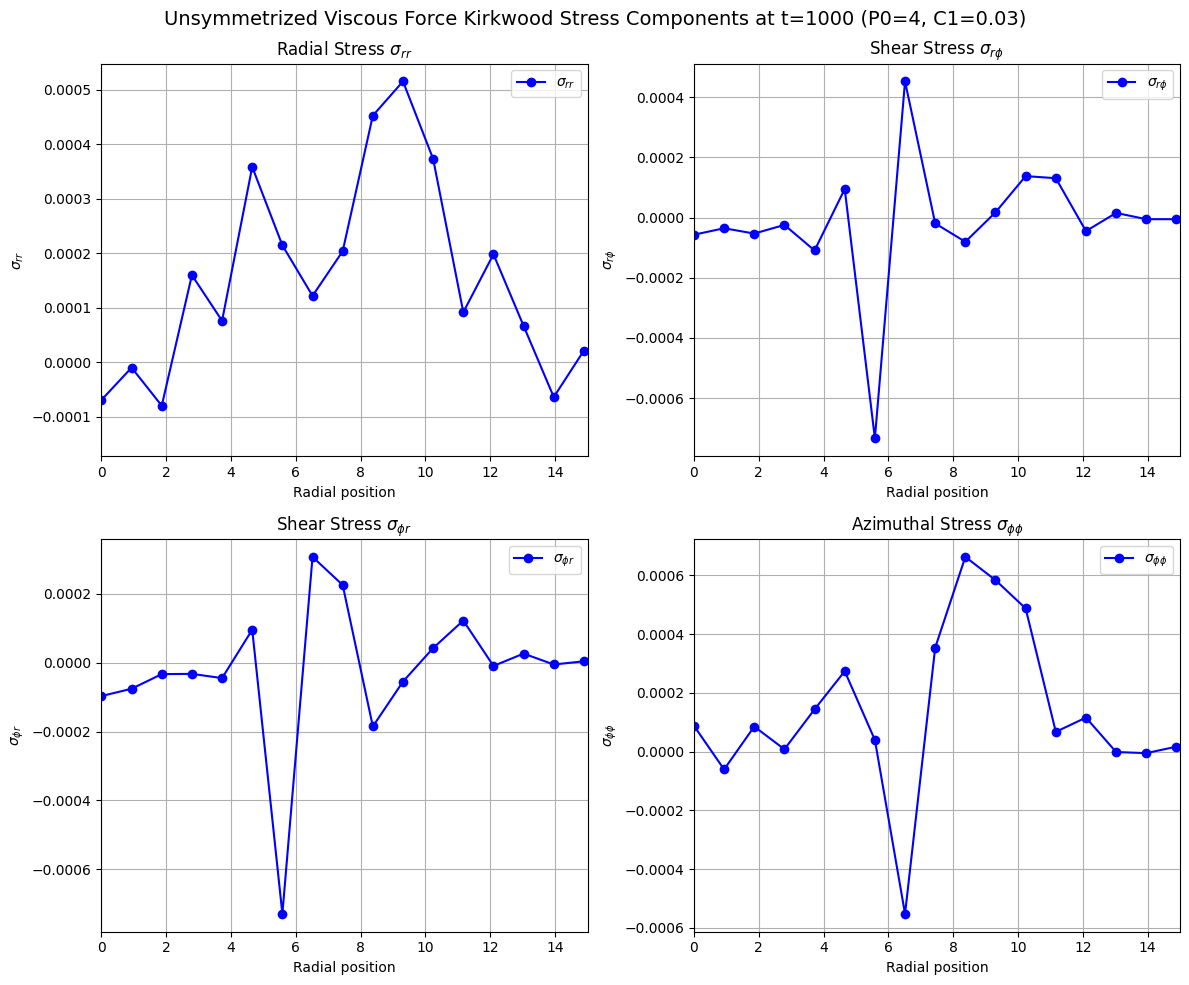

In [3]:
# plotting stress components in rr, rphi, phir, phiphi

# Plot stress components vs radial position
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. rr component
axes[0, 0].plot(np.array(bin_pos_total), np.array(trace_total)/2 + np.array(shear_xx_total), 'b-o', label=r'$\sigma_{rr}$')
axes[0, 0].set_xlim(0, r_a)  # Focus on the region inside the active droplet
axes[0, 0].set_xlabel('Radial position')
axes[0, 0].set_ylabel(r'$\sigma_{rr}$')
axes[0, 0].set_title(r'Radial Stress $\sigma_{rr}$')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. rphi component
axes[0, 1].plot(np.array(bin_pos_total), np.array(antisymmetric_xy_total) + np.array(shear_xy_total), 'b-o', label=r'$\sigma_{r\phi}$')
axes[0, 1].set_xlim(0, r_a)  # Focus on the region inside the active droplet
axes[0, 1].set_xlabel('Radial position')
axes[0, 1].set_ylabel(r'$\sigma_{r\phi}$')
axes[0, 1].set_title(r'Shear Stress $\sigma_{r\phi}$')
axes[0, 1].legend()
axes[0, 1].grid(True)

# 3. phir component
axes[1, 0].plot(np.array(bin_pos_total), -np.array(antisymmetric_xy_total) + np.array(shear_xy_total), 'b-o', label=r'$\sigma_{\phi r}$')
axes[1, 0].set_xlim(0, r_a)  # Focus on the region inside the active droplet
axes[1, 0].set_xlabel('Radial position')
axes[1, 0].set_ylabel(r'$\sigma_{\phi r}$')
axes[1, 0].set_title(r'Shear Stress $\sigma_{\phi r}$')
axes[1, 0].legend()
axes[1, 0].grid(True)

# 4. phiphi component
axes[1, 1].plot(np.array(bin_pos_total), np.array(trace_total)/2 - np.array(shear_xx_total), 'b-o', label=r'$\sigma_{\phi\phi}$')
axes[1, 1].set_xlim(0, r_a)  # Focus on the region inside the active droplet
axes[1, 1].set_xlabel('Radial position')
axes[1, 1].set_ylabel(r'$\sigma_{\phi\phi}$')
axes[1, 1].set_title(r'Azimuthal Stress $\sigma_{\phi\phi}$')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.suptitle(f'Unsymmetrized Viscous Force Kirkwood Stress Components at t={1000} (P0={P0}, C1={0.03})', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# calculating symmetrized viscous stress
"""
Calculate the Kirkwood stress of all cells at given time

Parameters:
-----------
folder_path : str
    Path to the data folder
kP : float
    Perimeter stiffness
P0 : float
    Target perimeter
time : int
    Time step
force_type : int
    1: cell force; 2: cell elastic force; 3: cell perimeter force;
    4: cell area force; 5: cell chiral force
rho_0 : float
    Density parameter
Lb : float
    Bin size parameter (multiplier for bin width)

Returns:
--------
Multiple numpy arrays containing stress components for total, active, and passive cells

NOTE: Q_theoretical is only defined for force_type = cell perimeter force (3)
"""

rho_0 = 1

# Read data files
c_v_xpos_list = read_file_folder_X(folder_path, f'X_{time}.dat')
c_v_ypos_list = read_file_folder_X(folder_path, f'Y_{time}.dat')
cVertices = read_file_folder_cVertices(folder_path, f'c_vertices_{time}.dat')
Nc = len(cVertices)

cForces = read_file_folder_cVertices(folder_path, f'cell_force_{time}.dat') # total chiral+elastic force on vertices

vNeighbors = read_v_xy_file_full(os.path.join(folder_path, f'v_neighbors_{time}.dat'))[:, 1].astype(int) # vertex neighbor list (excluding vertex ID column)

cActivity = read_file_folder_cell_bin_categories(folder_path, f'c_activity_{time}.dat')
_, perioY = read_file_folder(folder_path, f'perio_{time}.dat')

cbins = np.arange(0, perioY + Lb * perioY / np.sqrt(Nc), Lb * perioY / np.sqrt(Nc))
nbins = len(cbins)

data = read_v_xy_file_full(os.path.join(folder_path, f'v_xy_{time}.dat'))

v_velx = data [:,4] # x component of v_vel
v_vely = data [:,5] # y component of v_vel
v_fx = data [:,6] # x component of v_f
v_fy = data [:,7] # y component of v_f
v_x = data [:,2] # x position of vertices
v_y = data [:,3] # y position of vertices

v_viscous_dissipation_x = v_fx - gammaW * v_velx
v_viscous_dissipation_y = v_fy - gammaW * v_vely


Nv = len(v_velx)




# Calculate cell centers
xpos_center_active = []
ypos_center_active = []
xpos_center = np.zeros(Nc)
ypos_center = np.zeros(Nc)

for cid in range(Nc):
    cVertices_row = cVertices[cid]
    c_v_xpos_list_current = c_v_xpos_list[cid]
    c_v_ypos_list_current = c_v_ypos_list[cid]
    Nv_current = int(cVertices_row[1])

    # Calculate cell center
    vid_count = 0

    for vid in cVertices_row[2:2 + Nv_current]:
        xpos_center[cid] += c_v_xpos_list_current[vid_count]
        ypos_center[cid] += c_v_ypos_list_current[vid_count]
        vid_count += 1

    xpos_center[cid] /= Nv_current
    ypos_center[cid] /= Nv_current

    if cActivity[cid] == 1:
        xpos_center_active.append(xpos_center[cid])
        ypos_center_active.append(ypos_center[cid])

chiral_cell_center = np.zeros(2)
chiral_cell_center[0] = np.sum(xpos_center_active) / len(xpos_center_active)
chiral_cell_center[1] = np.sum(ypos_center_active) / len(ypos_center_active)

xpos_center = xpos_center - chiral_cell_center[0]
ypos_center = ypos_center - chiral_cell_center[1]

# Bin cells
cCategories = np.zeros(Nc, dtype=int)
for cid in range(Nc):
    dist = np.sqrt(xpos_center[cid]**2 + ypos_center[cid]**2)
    for bin_id in range(nbins - 1):
        if cbins[bin_id] <= dist < cbins[bin_id + 1]:
            cCategories[cid] = bin_id

# Initialize bin arrays
trace_bin = np.zeros(nbins)
trace_theoretical_bin = np.zeros(nbins)
trace_bin_active = np.zeros(nbins)
trace_theoretical_bin_active = np.zeros(nbins)
antisymmetric_part_bin = np.zeros((2 * nbins, 2))
antisymmetric_part_bin_active = np.zeros((2 * nbins, 2))
shear_part_bin = np.zeros((2 * nbins, 2))
shear_part_bin_active = np.zeros((2 * nbins, 2))
trace_bin_passive = np.zeros(nbins)
trace_theoretical_bin_passive = np.zeros(nbins)
antisymmetric_part_bin_passive = np.zeros((2 * nbins, 2))
shear_part_bin_passive = np.zeros((2 * nbins, 2))
Q_theoretical_bin = np.zeros((2 * nbins, 2))
Q_bin = np.zeros((2 * nbins, 2))
bin_count = np.zeros(nbins)
bin_count_active = np.zeros(nbins)
bin_count_passive = np.zeros(nbins)

# Calculate viscous stress for each cell -1/Ac * sum(r_i outer v_dissipation_i/z_i)
for cid in range(Nc):
    cVertices_row = cVertices[cid] # list of [cell_id, Nv, v1_id, v2_id, ..., vNv_id]
    c_v_xpos_list_current = np.array(c_v_xpos_list[cid]) - xpos_center[cid] - chiral_cell_center[0]
    c_v_ypos_list_current = np.array(c_v_ypos_list[cid]) - ypos_center[cid] - chiral_cell_center[1]
    Nv_current = int(cVertices_row[1])
    # cForces_row = cForces[cid] # list of [cell_id, Nv, Fx1, Fy1, Fx2, Fy2, ..., FxNv, FyNv]

    
    # # Extract forces (cForces_row: list of [Nv, Fx1, Fy1, Fx2, Fy2, ..., FxNv, FyNv])
    # vFx_list_current = np.asarray(cForces_row[1::2])
    # vFy_list_current = np.asarray(cForces_row[2::2])



    # Calculate area and perimeter
    area = 0
    perimeter = 0
    for i in range(Nv_current - 1):
        area += abs(0.5 * (c_v_xpos_list_current[i + 1] * c_v_ypos_list_current[i] -
                            c_v_xpos_list_current[i] * c_v_ypos_list_current[i + 1]))
        perimeter += np.sqrt((c_v_xpos_list_current[i + 1] - c_v_xpos_list_current[i])**2 +
                                (c_v_ypos_list_current[i + 1] - c_v_ypos_list_current[i])**2)

    area += abs(0.5 * (c_v_xpos_list_current[0] * c_v_ypos_list_current[Nv_current - 1] -
                        c_v_xpos_list_current[Nv_current - 1] * c_v_ypos_list_current[0]))
    perimeter += np.sqrt((c_v_xpos_list_current[0] - c_v_xpos_list_current[Nv_current - 1])**2 +
                            (c_v_ypos_list_current[0] - c_v_ypos_list_current[Nv_current - 1])**2)

    # Calculate Q tensor
    l_current = np.zeros(2)
    Q = np.zeros((2, 2))
    for i in range(Nv_current - 1):
        l_current[0] = c_v_xpos_list_current[i + 1] - c_v_xpos_list_current[i]
        l_current[1] = c_v_ypos_list_current[i + 1] - c_v_ypos_list_current[i]
        edgeLength = np.sqrt(l_current @ l_current)
        Q += np.outer(l_current, l_current) / edgeLength / perimeter

    l_current[0] = c_v_xpos_list_current[0] - c_v_xpos_list_current[Nv_current - 1]
    l_current[1] = c_v_ypos_list_current[0] - c_v_ypos_list_current[Nv_current - 1]
    edgeLength = np.sqrt(l_current @ l_current)
    Q += np.outer(l_current, l_current) / edgeLength / perimeter - 0.5 * np.eye(2)

    
    # Calculate stress tensor
    r_current = np.zeros(2)
    v_current = np.zeros(2)
    outerProduct_current = np.zeros((2, 2))

    for i in range(Nv_current):
        vid = int(cVertices_row[2 + i])-1 # vertex ID (adjusted for 0-based indexing)
        z_i = vNeighbors[vid] # number of cells sharing this vertex
        r_current[0] = c_v_xpos_list_current[i]
        r_current[1] = c_v_ypos_list_current[i]
        v_current[0] = v_viscous_dissipation_x[vid] / z_i
        v_current[1] = v_viscous_dissipation_y[vid] / z_i
        outerProduct_current += 0.5 * np.outer(r_current, v_current) + 0.5 * np.outer(v_current, r_current) # symmetrized outer product

    outerProduct_current = -rho_0 * outerProduct_current / area
    theta = get_rotation_angle(xpos_center[cid], ypos_center[cid])
    sigma_current = tensor_coordinate_transformation(outerProduct_current, theta)
    isotropic_part_current = 0.5 * np.trace(sigma_current) * np.eye(2)
    antisymmetric_part_current = 0.5 * (sigma_current - sigma_current.T)
    shear_part_current = 0.5 * (sigma_current + sigma_current.T - 2 * isotropic_part_current)
    Q_theoretical = area / (2 * kP) / perimeter / (perimeter - P0) * sigma_current - 0.5 * np.eye(2)
    Q = tensor_coordinate_transformation(Q, theta)


    # Store in appropriate bins
    if cActivity[cid] > 0.0:
        trace_theoretical_bin_active[cCategories[cid]] += 2 * (area - 1) + 2 * kP / area * (perimeter - P0) * perimeter
        trace_bin_active[cCategories[cid]] += np.trace(sigma_current)
        antisymmetric_part_bin_active[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += antisymmetric_part_current
        shear_part_bin_active[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += shear_part_current
        bin_count_active[cCategories[cid]] += 1
    else:
        trace_theoretical_bin_passive[cCategories[cid]] += 2 * (area - 1) + 2 * kP / area * (perimeter - P0) * perimeter
        trace_bin_passive[cCategories[cid]] += np.trace(sigma_current)
        antisymmetric_part_bin_passive[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += antisymmetric_part_current
        shear_part_bin_passive[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += shear_part_current
        bin_count_passive[cCategories[cid]] += 1

    trace_theoretical_bin[cCategories[cid]] += 2 * (area - 1) + 2 * kP / area * (perimeter - P0) * perimeter
    trace_bin[cCategories[cid]] += np.trace(sigma_current)
    antisymmetric_part_bin[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += antisymmetric_part_current
    shear_part_bin[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += shear_part_current
    bin_count[cCategories[cid]] += 1
    Q_theoretical_bin[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += Q_theoretical
    Q_bin[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += Q

# Average over bins
trace_total = []
trace_active = []
trace_passive = []
trace_theoretical_total = []
trace_theoretical_active = []
trace_theoretical_passive = []
antisymmetric_xy_total = []
antisymmetric_xy_active = []
antisymmetric_xy_passive = []
shear_xx_total = []
shear_xy_total = []
shear_xx_active = []
shear_xy_active = []
shear_xx_passive = []
shear_xy_passive = []
shear_det_active = []
shear_det_passive = []
shear_angle_active = []
shear_angle_passive = []
Q_angle_theoretical = []
Q_det_theoretical = []
Q_angle = []
Q_det = []
bin_pos_total = []
bin_pos_active = []
bin_pos_passive = []

for bin_id in range(len(bin_count_active)):
    if bin_count_active[bin_id] > 0:
        trace_theoretical_active.append(trace_theoretical_bin_active[bin_id] / bin_count_active[bin_id])
        trace_active.append(trace_bin_active[bin_id] / bin_count_active[bin_id])
        antisymmetric_xy_active.append(antisymmetric_part_bin_active[2 * bin_id, 1] / bin_count_active[bin_id])
        shear_xx_active.append(shear_part_bin_active[2 * bin_id, 0] / bin_count_active[bin_id])
        shear_xy_active.append(shear_part_bin_active[2 * bin_id, 1] / bin_count_active[bin_id])
        shear_det_active.append(np.linalg.det(shear_part_bin_active[2 * bin_id:2 * bin_id + 2, :] / bin_count_active[bin_id]))
        shear_angle_active.append(get_Q_angle(shear_part_bin_active[2 * bin_id:2 * bin_id + 2, :] / bin_count_active[bin_id]))
        bin_pos_active.append(cbins[bin_id])

for bin_id in range(len(bin_count_passive)):
    if bin_count_passive[bin_id] > 0:
        trace_theoretical_passive.append(trace_theoretical_bin_passive[bin_id] / bin_count_passive[bin_id])
        trace_passive.append(trace_bin_passive[bin_id] / bin_count_passive[bin_id])
        antisymmetric_xy_passive.append(antisymmetric_part_bin_passive[2 * bin_id, 1] / bin_count_passive[bin_id])
        shear_xx_passive.append(shear_part_bin_passive[2 * bin_id, 0] / bin_count_passive[bin_id])
        shear_xy_passive.append(shear_part_bin_passive[2 * bin_id, 1] / bin_count_passive[bin_id])
        shear_det_passive.append(np.linalg.det(shear_part_bin_passive[2 * bin_id:2 * bin_id + 2, :] / bin_count_passive[bin_id]))
        shear_angle_passive.append(get_Q_angle(shear_part_bin_passive[2 * bin_id:2 * bin_id + 2, :] / bin_count_passive[bin_id]))
        bin_pos_passive.append(cbins[bin_id])

for bin_id in range(len(bin_count)):
    if bin_count[bin_id] > 0:
        trace_theoretical_total.append(trace_theoretical_bin[bin_id] / bin_count[bin_id])
        trace_total.append(trace_bin[bin_id] / bin_count[bin_id])
        antisymmetric_xy_total.append(antisymmetric_part_bin[2 * bin_id, 1] / bin_count[bin_id])
        shear_xx_total.append(shear_part_bin[2 * bin_id, 0] / bin_count[bin_id])
        shear_xy_total.append(shear_part_bin[2 * bin_id, 1] / bin_count[bin_id])
        bin_pos_total.append(cbins[bin_id])
        Q_det_theoretical.append(np.linalg.det(Q_theoretical_bin[2 * bin_id:2 * bin_id + 2, :] / bin_count[bin_id]))
        Q_angle_theoretical.append(get_Q_angle(Q_theoretical_bin[2 * bin_id:2 * bin_id + 2, :] / bin_count[bin_id]))
        Q_det.append(np.linalg.det(Q_bin[2 * bin_id:2 * bin_id + 2, :] / bin_count[bin_id]))
        Q_angle.append(get_Q_angle(Q_bin[2 * bin_id:2 * bin_id + 2, :] / bin_count[bin_id]))









/tmp/ipykernel_1928998/179809237.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cbins = np.arange(0, perioY + Lb * perioY / np.sqrt(Nc), Lb * perioY / np.sqrt(Nc))


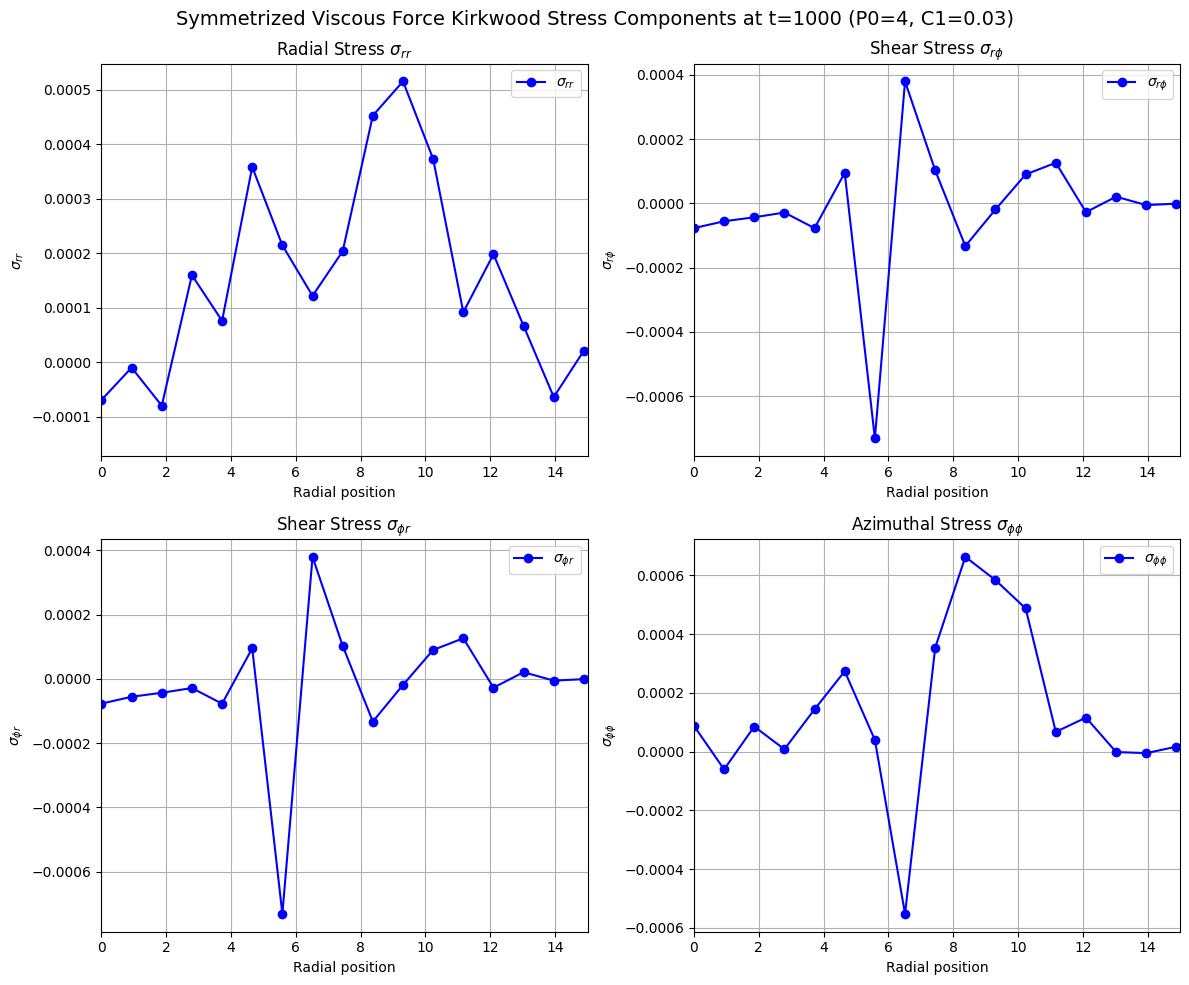

In [5]:
# plotting stress components in rr, rphi, phir, phiphi

# Plot stress components vs radial position
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. rr component
axes[0, 0].plot(np.array(bin_pos_total), np.array(trace_total)/2 + np.array(shear_xx_total), 'b-o', label=r'$\sigma_{rr}$')
axes[0, 0].set_xlim(0, r_a)  # Focus on the region inside the active droplet
axes[0, 0].set_xlabel('Radial position')
axes[0, 0].set_ylabel(r'$\sigma_{rr}$')
axes[0, 0].set_title(r'Radial Stress $\sigma_{rr}$')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. rphi component
axes[0, 1].plot(np.array(bin_pos_total), np.array(antisymmetric_xy_total) + np.array(shear_xy_total), 'b-o', label=r'$\sigma_{r\phi}$')
axes[0, 1].set_xlim(0, r_a)  # Focus on the region inside the active droplet
axes[0, 1].set_xlabel('Radial position')
axes[0, 1].set_ylabel(r'$\sigma_{r\phi}$')
axes[0, 1].set_title(r'Shear Stress $\sigma_{r\phi}$')
axes[0, 1].legend()
axes[0, 1].grid(True)

# 3. phir component
axes[1, 0].plot(np.array(bin_pos_total), -np.array(antisymmetric_xy_total) + np.array(shear_xy_total), 'b-o', label=r'$\sigma_{\phi r}$')
axes[1, 0].set_xlim(0, r_a)  # Focus on the region inside the active droplet
axes[1, 0].set_xlabel('Radial position')
axes[1, 0].set_ylabel(r'$\sigma_{\phi r}$')
axes[1, 0].set_title(r'Shear Stress $\sigma_{\phi r}$')
axes[1, 0].legend()
axes[1, 0].grid(True)

# 4. phiphi component
axes[1, 1].plot(np.array(bin_pos_total), np.array(trace_total)/2 - np.array(shear_xx_total), 'b-o', label=r'$\sigma_{\phi\phi}$')
axes[1, 1].set_xlim(0, r_a)  # Focus on the region inside the active droplet
axes[1, 1].set_xlabel('Radial position')
axes[1, 1].set_ylabel(r'$\sigma_{\phi\phi}$')
axes[1, 1].set_title(r'Azimuthal Stress $\sigma_{\phi\phi}$')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.suptitle(f'Symmetrized Viscous Force Kirkwood Stress Components at t={1000} (P0={P0}, C1={0.03})', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# difference between symmetrized and unsymmetrized stress

"""
Calculate the Kirkwood stress of all cells at given time

Parameters:
-----------
folder_path : str
    Path to the data folder
kP : float
    Perimeter stiffness
P0 : float
    Target perimeter
time : int
    Time step
force_type : int
    1: cell force; 2: cell elastic force; 3: cell perimeter force;
    4: cell area force; 5: cell chiral force
rho_0 : float
    Density parameter
Lb : float
    Bin size parameter (multiplier for bin width)

Returns:
--------
Multiple numpy arrays containing stress components for total, active, and passive cells

NOTE: Q_theoretical is only defined for force_type = cell perimeter force (3)
"""

rho_0 = 1

# Read data files
c_v_xpos_list = read_file_folder_X(folder_path, f'X_{time}.dat')
c_v_ypos_list = read_file_folder_X(folder_path, f'Y_{time}.dat')
cVertices = read_file_folder_cVertices(folder_path, f'c_vertices_{time}.dat')
Nc = len(cVertices)

cForces = read_file_folder_cVertices(folder_path, f'cell_force_{time}.dat') # total chiral+elastic force on vertices

vNeighbors = read_v_xy_file_full(os.path.join(folder_path, f'v_neighbors_{time}.dat'))[:, 1].astype(int) # vertex neighbor list (excluding vertex ID column)

cActivity = read_file_folder_cell_bin_categories(folder_path, f'c_activity_{time}.dat')
_, perioY = read_file_folder(folder_path, f'perio_{time}.dat')

cbins = np.arange(0, perioY + Lb * perioY / np.sqrt(Nc), Lb * perioY / np.sqrt(Nc))
nbins = len(cbins)

data = read_v_xy_file_full(os.path.join(folder_path, f'v_xy_{time}.dat'))

v_velx = data [:,4] # x component of v_vel
v_vely = data [:,5] # y component of v_vel
v_fx = data [:,6] # x component of v_f
v_fy = data [:,7] # y component of v_f
v_x = data [:,2] # x position of vertices
v_y = data [:,3] # y position of vertices

v_viscous_dissipation_x = v_fx - gammaW * v_velx
v_viscous_dissipation_y = v_fy - gammaW * v_vely


Nv = len(v_velx)




# Calculate cell centers
xpos_center_active = []
ypos_center_active = []
xpos_center = np.zeros(Nc)
ypos_center = np.zeros(Nc)

for cid in range(Nc):
    cVertices_row = cVertices[cid]
    c_v_xpos_list_current = c_v_xpos_list[cid]
    c_v_ypos_list_current = c_v_ypos_list[cid]
    Nv_current = int(cVertices_row[1])

    # Calculate cell center
    vid_count = 0

    for vid in cVertices_row[2:2 + Nv_current]:
        xpos_center[cid] += c_v_xpos_list_current[vid_count]
        ypos_center[cid] += c_v_ypos_list_current[vid_count]
        vid_count += 1

    xpos_center[cid] /= Nv_current
    ypos_center[cid] /= Nv_current

    if cActivity[cid] == 1:
        xpos_center_active.append(xpos_center[cid])
        ypos_center_active.append(ypos_center[cid])

chiral_cell_center = np.zeros(2)
chiral_cell_center[0] = np.sum(xpos_center_active) / len(xpos_center_active)
chiral_cell_center[1] = np.sum(ypos_center_active) / len(ypos_center_active)

xpos_center = xpos_center - chiral_cell_center[0]
ypos_center = ypos_center - chiral_cell_center[1]

# Bin cells
cCategories = np.zeros(Nc, dtype=int)
for cid in range(Nc):
    dist = np.sqrt(xpos_center[cid]**2 + ypos_center[cid]**2)
    for bin_id in range(nbins - 1):
        if cbins[bin_id] <= dist < cbins[bin_id + 1]:
            cCategories[cid] = bin_id

# Initialize bin arrays
trace_bin = np.zeros(nbins)
trace_theoretical_bin = np.zeros(nbins)
trace_bin_active = np.zeros(nbins)
trace_theoretical_bin_active = np.zeros(nbins)
antisymmetric_part_bin = np.zeros((2 * nbins, 2))
antisymmetric_part_bin_active = np.zeros((2 * nbins, 2))
shear_part_bin = np.zeros((2 * nbins, 2))
shear_part_bin_active = np.zeros((2 * nbins, 2))
trace_bin_passive = np.zeros(nbins)
trace_theoretical_bin_passive = np.zeros(nbins)
antisymmetric_part_bin_passive = np.zeros((2 * nbins, 2))
shear_part_bin_passive = np.zeros((2 * nbins, 2))
Q_theoretical_bin = np.zeros((2 * nbins, 2))
Q_bin = np.zeros((2 * nbins, 2))
bin_count = np.zeros(nbins)
bin_count_active = np.zeros(nbins)
bin_count_passive = np.zeros(nbins)

# Calculate viscous stress for each cell -1/Ac * sum(r_i outer v_dissipation_i/z_i)
for cid in range(Nc):
    cVertices_row = cVertices[cid] # list of [cell_id, Nv, v1_id, v2_id, ..., vNv_id]
    c_v_xpos_list_current = np.array(c_v_xpos_list[cid]) - xpos_center[cid] - chiral_cell_center[0]
    c_v_ypos_list_current = np.array(c_v_ypos_list[cid]) - ypos_center[cid] - chiral_cell_center[1]
    Nv_current = int(cVertices_row[1])
    # cForces_row = cForces[cid] # list of [cell_id, Nv, Fx1, Fy1, Fx2, Fy2, ..., FxNv, FyNv]

    
    # # Extract forces (cForces_row: list of [Nv, Fx1, Fy1, Fx2, Fy2, ..., FxNv, FyNv])
    # vFx_list_current = np.asarray(cForces_row[1::2])
    # vFy_list_current = np.asarray(cForces_row[2::2])



    # Calculate area and perimeter
    area = 0
    perimeter = 0
    for i in range(Nv_current - 1):
        area += abs(0.5 * (c_v_xpos_list_current[i + 1] * c_v_ypos_list_current[i] -
                            c_v_xpos_list_current[i] * c_v_ypos_list_current[i + 1]))
        perimeter += np.sqrt((c_v_xpos_list_current[i + 1] - c_v_xpos_list_current[i])**2 +
                                (c_v_ypos_list_current[i + 1] - c_v_ypos_list_current[i])**2)

    area += abs(0.5 * (c_v_xpos_list_current[0] * c_v_ypos_list_current[Nv_current - 1] -
                        c_v_xpos_list_current[Nv_current - 1] * c_v_ypos_list_current[0]))
    perimeter += np.sqrt((c_v_xpos_list_current[0] - c_v_xpos_list_current[Nv_current - 1])**2 +
                            (c_v_ypos_list_current[0] - c_v_ypos_list_current[Nv_current - 1])**2)

    # Calculate Q tensor
    l_current = np.zeros(2)
    Q = np.zeros((2, 2))
    for i in range(Nv_current - 1):
        l_current[0] = c_v_xpos_list_current[i + 1] - c_v_xpos_list_current[i]
        l_current[1] = c_v_ypos_list_current[i + 1] - c_v_ypos_list_current[i]
        edgeLength = np.sqrt(l_current @ l_current)
        Q += np.outer(l_current, l_current) / edgeLength / perimeter

    l_current[0] = c_v_xpos_list_current[0] - c_v_xpos_list_current[Nv_current - 1]
    l_current[1] = c_v_ypos_list_current[0] - c_v_ypos_list_current[Nv_current - 1]
    edgeLength = np.sqrt(l_current @ l_current)
    Q += np.outer(l_current, l_current) / edgeLength / perimeter - 0.5 * np.eye(2)

    
    # Calculate stress tensor
    r_current = np.zeros(2)
    v_current = np.zeros(2)
    outerProduct_current = np.zeros((2, 2))

    for i in range(Nv_current):
        vid = int(cVertices_row[2 + i])-1 # vertex ID (adjusted for 0-based indexing)
        z_i = vNeighbors[vid] # number of cells sharing this vertex
        r_current[0] = c_v_xpos_list_current[i]
        r_current[1] = c_v_ypos_list_current[i]
        v_current[0] = v_viscous_dissipation_x[vid] / z_i
        v_current[1] = v_viscous_dissipation_y[vid] / z_i
        outerProduct_current += -0.5 * np.outer(r_current, v_current) + 0.5 * np.outer(v_current, r_current) # difference between symmetrized and unsymmetrized outer product

    outerProduct_current = -rho_0 * outerProduct_current / area
    theta = get_rotation_angle(xpos_center[cid], ypos_center[cid])
    sigma_current = tensor_coordinate_transformation(outerProduct_current, theta)
    isotropic_part_current = 0.5 * np.trace(sigma_current) * np.eye(2)
    antisymmetric_part_current = 0.5 * (sigma_current - sigma_current.T)
    shear_part_current = 0.5 * (sigma_current + sigma_current.T - 2 * isotropic_part_current)
    Q_theoretical = area / (2 * kP) / perimeter / (perimeter - P0) * sigma_current - 0.5 * np.eye(2)
    Q = tensor_coordinate_transformation(Q, theta)


    # Store in appropriate bins
    if cActivity[cid] > 0.0:
        trace_theoretical_bin_active[cCategories[cid]] += 2 * (area - 1) + 2 * kP / area * (perimeter - P0) * perimeter
        trace_bin_active[cCategories[cid]] += np.trace(sigma_current)
        antisymmetric_part_bin_active[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += antisymmetric_part_current
        shear_part_bin_active[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += shear_part_current
        bin_count_active[cCategories[cid]] += 1
    else:
        trace_theoretical_bin_passive[cCategories[cid]] += 2 * (area - 1) + 2 * kP / area * (perimeter - P0) * perimeter
        trace_bin_passive[cCategories[cid]] += np.trace(sigma_current)
        antisymmetric_part_bin_passive[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += antisymmetric_part_current
        shear_part_bin_passive[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += shear_part_current
        bin_count_passive[cCategories[cid]] += 1

    trace_theoretical_bin[cCategories[cid]] += 2 * (area - 1) + 2 * kP / area * (perimeter - P0) * perimeter
    trace_bin[cCategories[cid]] += np.trace(sigma_current)
    antisymmetric_part_bin[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += antisymmetric_part_current
    shear_part_bin[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += shear_part_current
    bin_count[cCategories[cid]] += 1
    Q_theoretical_bin[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += Q_theoretical
    Q_bin[2 * cCategories[cid]:2 * cCategories[cid] + 2, :] += Q

# Average over bins
trace_total = []
trace_active = []
trace_passive = []
trace_theoretical_total = []
trace_theoretical_active = []
trace_theoretical_passive = []
antisymmetric_xy_total = []
antisymmetric_xy_active = []
antisymmetric_xy_passive = []
shear_xx_total = []
shear_xy_total = []
shear_xx_active = []
shear_xy_active = []
shear_xx_passive = []
shear_xy_passive = []
shear_det_active = []
shear_det_passive = []
shear_angle_active = []
shear_angle_passive = []
Q_angle_theoretical = []
Q_det_theoretical = []
Q_angle = []
Q_det = []
bin_pos_total = []
bin_pos_active = []
bin_pos_passive = []

for bin_id in range(len(bin_count_active)):
    if bin_count_active[bin_id] > 0:
        trace_theoretical_active.append(trace_theoretical_bin_active[bin_id] / bin_count_active[bin_id])
        trace_active.append(trace_bin_active[bin_id] / bin_count_active[bin_id])
        antisymmetric_xy_active.append(antisymmetric_part_bin_active[2 * bin_id, 1] / bin_count_active[bin_id])
        shear_xx_active.append(shear_part_bin_active[2 * bin_id, 0] / bin_count_active[bin_id])
        shear_xy_active.append(shear_part_bin_active[2 * bin_id, 1] / bin_count_active[bin_id])
        shear_det_active.append(np.linalg.det(shear_part_bin_active[2 * bin_id:2 * bin_id + 2, :] / bin_count_active[bin_id]))
        shear_angle_active.append(get_Q_angle(shear_part_bin_active[2 * bin_id:2 * bin_id + 2, :] / bin_count_active[bin_id]))
        bin_pos_active.append(cbins[bin_id])

for bin_id in range(len(bin_count_passive)):
    if bin_count_passive[bin_id] > 0:
        trace_theoretical_passive.append(trace_theoretical_bin_passive[bin_id] / bin_count_passive[bin_id])
        trace_passive.append(trace_bin_passive[bin_id] / bin_count_passive[bin_id])
        antisymmetric_xy_passive.append(antisymmetric_part_bin_passive[2 * bin_id, 1] / bin_count_passive[bin_id])
        shear_xx_passive.append(shear_part_bin_passive[2 * bin_id, 0] / bin_count_passive[bin_id])
        shear_xy_passive.append(shear_part_bin_passive[2 * bin_id, 1] / bin_count_passive[bin_id])
        shear_det_passive.append(np.linalg.det(shear_part_bin_passive[2 * bin_id:2 * bin_id + 2, :] / bin_count_passive[bin_id]))
        shear_angle_passive.append(get_Q_angle(shear_part_bin_passive[2 * bin_id:2 * bin_id + 2, :] / bin_count_passive[bin_id]))
        bin_pos_passive.append(cbins[bin_id])

for bin_id in range(len(bin_count)):
    if bin_count[bin_id] > 0:
        trace_theoretical_total.append(trace_theoretical_bin[bin_id] / bin_count[bin_id])
        trace_total.append(trace_bin[bin_id] / bin_count[bin_id])
        antisymmetric_xy_total.append(antisymmetric_part_bin[2 * bin_id, 1] / bin_count[bin_id])
        shear_xx_total.append(shear_part_bin[2 * bin_id, 0] / bin_count[bin_id])
        shear_xy_total.append(shear_part_bin[2 * bin_id, 1] / bin_count[bin_id])
        bin_pos_total.append(cbins[bin_id])
        Q_det_theoretical.append(np.linalg.det(Q_theoretical_bin[2 * bin_id:2 * bin_id + 2, :] / bin_count[bin_id]))
        Q_angle_theoretical.append(get_Q_angle(Q_theoretical_bin[2 * bin_id:2 * bin_id + 2, :] / bin_count[bin_id]))
        Q_det.append(np.linalg.det(Q_bin[2 * bin_id:2 * bin_id + 2, :] / bin_count[bin_id]))
        Q_angle.append(get_Q_angle(Q_bin[2 * bin_id:2 * bin_id + 2, :] / bin_count[bin_id]))









/tmp/ipykernel_1928998/2373921903.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cbins = np.arange(0, perioY + Lb * perioY / np.sqrt(Nc), Lb * perioY / np.sqrt(Nc))


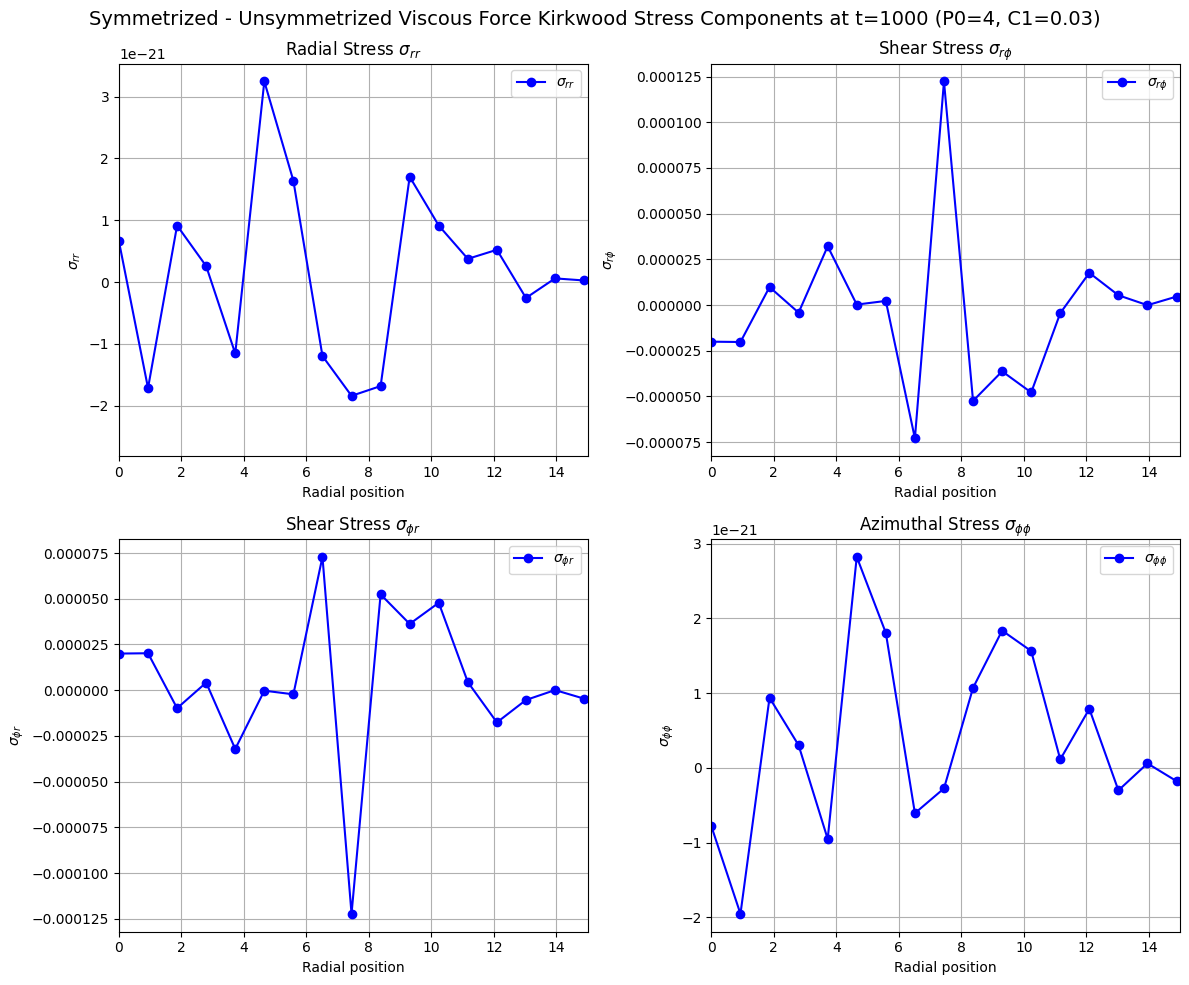

In [7]:
# plotting stress components in rr, rphi, phir, phiphi

# Plot stress components vs radial position
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. rr component
axes[0, 0].plot(np.array(bin_pos_total), np.array(trace_total)/2 + np.array(shear_xx_total), 'b-o', label=r'$\sigma_{rr}$')
axes[0, 0].set_xlim(0, r_a)  # Focus on the region inside the active droplet
axes[0, 0].set_xlabel('Radial position')
axes[0, 0].set_ylabel(r'$\sigma_{rr}$')
axes[0, 0].set_title(r'Radial Stress $\sigma_{rr}$')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. rphi component
axes[0, 1].plot(np.array(bin_pos_total), np.array(antisymmetric_xy_total) + np.array(shear_xy_total), 'b-o', label=r'$\sigma_{r\phi}$')
axes[0, 1].set_xlim(0, r_a)  # Focus on the region inside the active droplet
axes[0, 1].set_xlabel('Radial position')
axes[0, 1].set_ylabel(r'$\sigma_{r\phi}$')
axes[0, 1].set_title(r'Shear Stress $\sigma_{r\phi}$')
axes[0, 1].legend()
axes[0, 1].grid(True)

# 3. phir component
axes[1, 0].plot(np.array(bin_pos_total), -np.array(antisymmetric_xy_total) + np.array(shear_xy_total), 'b-o', label=r'$\sigma_{\phi r}$')
axes[1, 0].set_xlim(0, r_a)  # Focus on the region inside the active droplet
axes[1, 0].set_xlabel('Radial position')
axes[1, 0].set_ylabel(r'$\sigma_{\phi r}$')
axes[1, 0].set_title(r'Shear Stress $\sigma_{\phi r}$')
axes[1, 0].legend()
axes[1, 0].grid(True)

# 4. phiphi component
axes[1, 1].plot(np.array(bin_pos_total), np.array(trace_total)/2 - np.array(shear_xx_total), 'b-o', label=r'$\sigma_{\phi\phi}$')
axes[1, 1].set_xlim(0, r_a)  # Focus on the region inside the active droplet
axes[1, 1].set_xlabel('Radial position')
axes[1, 1].set_ylabel(r'$\sigma_{\phi\phi}$')
axes[1, 1].set_title(r'Azimuthal Stress $\sigma_{\phi\phi}$')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.suptitle(f'Symmetrized - Unsymmetrized Viscous Force Kirkwood Stress Components at t={1000} (P0={P0}, C1={0.03})', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
def read_v_xy_file_full(filepath):
    """
    Read all columns from v_xy_*.dat file
    
    Returns:
    --------
    data : numpy array
        Full data array with all columns
    """
    data = np.loadtxt(filepath, comments='#')
    return data

In [9]:
# System parameters
Nx = 20
gammaW = 1
zetaW = 1e-5
disorder = 0.001
kP = 0.01
dynamics = 2

# Parameter lists for analysis
P0_list = np.array([3.4, 3.5, 3.6])
C1_list = np.array([0.05, 0.05, 0.05])
disorder_list = np.array([0.02, 0.02])

# Color schemes for plotting
Color_list_type1 = np.array([[0, 1, 1], [0, 0.4471, 0.7412], [0.3020, 0.7451, 0.9333]])
Color_list_type2 = np.array([[0.6353, 0.0784, 0.1843], [1.0000, 0, 0], [1.0000, 0.4784, 0.5490]])
color1 = np.array([0, 1, 1])
color2 = np.array([1.0000, 0.4784, 0.5490])

# Simulation parameters
P0 = 3.9
C1 = 0.05
dw = 100
di = 100
tMAX = 10000
seed = 0
count = 1
start_time = tMAX-4*dw

time = start_time

Lb=1

# force_type: 1=cell force, 2=elastic force, 3=perimeter force, 4=area force, 5=chiral force
force_type = 1
rho_0 = 1

In [10]:
filepath = f'/mnt/users/wangg/VertexModelChiralWetEdges/output/out_Nx_{Nx}_kA_0.5_kP_{kP}_P0_{P0}_disorder_{disorder}_tMAX_{tMAX}_dw_{dw}_di_{di}_ca1_{C1}_ca2_0_iC_0_iP_0.25_iS_{seed}_iT_0_dynamics_{dynamics}_gammaW_{gammaW}_zetaW_{zetaW}/v_xy_{time}.dat'

data = read_v_xy_file_full(filepath)
print(f"Data shape: {data.shape}")
print(f"Columns: {data.shape[1] if data.ndim > 1 else 1}")
print(data[:,0])

v_fx = data [:,4]
v_fy = data [:,5]
v_x = data [:,2]
v_y = data [:,3]

Nv = len(v_fx)


# Read data files
c_v_xpos_list = read_file_folder_X(Nx, kP, P0, C1, dw, di, disorder, tMAX, seed, f'X_{time}.dat', dynamics, gammaW, zetaW)
c_v_ypos_list = read_file_folder_X(Nx, kP, P0, C1, dw, di, disorder, tMAX, seed, f'Y_{time}.dat', dynamics, gammaW, zetaW)
cVertices = read_file_folder_cVertices(Nx, kP, P0, C1, dw, di, disorder, tMAX, seed, f'c_vertices_{time}.dat', dynamics, gammaW, zetaW)
Nc = len(cVertices)

cActivity = read_file_folder_cell_bin_categories(Nx, kP, P0, C1, dw, di, disorder, tMAX, seed, f'c_activity_{time}.dat', dynamics, gammaW, zetaW)
_, perioY = read_file_folder(Nx, kP, P0, C1, dw, di, disorder, tMAX, seed, f'perio_{time}.dat', dynamics, gammaW, zetaW)

# Calculate cell centers
xpos_center_active = []
ypos_center_active = []
xpos_center = np.zeros(Nc)
ypos_center = np.zeros(Nc)

for cid in range(Nc):
    cVertices_row = cVertices[cid]
    c_v_xpos_list_current = c_v_xpos_list[cid]
    c_v_ypos_list_current = c_v_ypos_list[cid]
    Nv_current = int(cVertices_row[1])

    # Calculate cell center
    vid_count = 0

    for vid in cVertices_row[2:2 + Nv_current]:
        xpos_center[cid] += c_v_xpos_list_current[vid_count]
        ypos_center[cid] += c_v_ypos_list_current[vid_count]
        vid_count += 1

    xpos_center[cid] /= Nv_current
    ypos_center[cid] /= Nv_current

    if cActivity[cid] == 1:
        xpos_center_active.append(xpos_center[cid])
        ypos_center_active.append(ypos_center[cid])

chiral_cell_center = np.zeros(2)
chiral_cell_center[0] = np.sum(xpos_center_active) / len(xpos_center_active)
chiral_cell_center[1] = np.sum(ypos_center_active) / len(ypos_center_active)

v_x_rel = v_x - chiral_cell_center[0]
v_y_rel = v_y - chiral_cell_center[1]

FileNotFoundError: /mnt/users/wangg/VertexModelChiralWetEdges/output/out_Nx_20_kA_0.5_kP_0.01_P0_3.9_disorder_0.001_tMAX_10000_dw_100_di_100_ca1_0.05_ca2_0_iC_0_iP_0.25_iS_0_iT_0_dynamics_2_gammaW_1_zetaW_1e-05/v_xy_9600.dat not found.

In [ ]:
print('v_x_rel:', v_x_rel)
print('v_y_rel:', v_y_rel)

v_x_rel: [-1.01253708e+01 -9.75590619e+00 -9.63199267e+00 -1.02427013e+01
 -9.11781712e+00 -8.71582431e+00 -8.46855921e+00 -9.13026792e+00
 -7.95520269e+00 -7.51179241e+00 -7.47962020e+00 -8.09697294e+00
 -7.10383801e+00 -6.26746470e+00 -6.55612615e+00 -6.93014055e+00
 -6.03406536e+00 -5.27427973e+00 -5.42931466e+00 -5.85366318e+00
 -4.73754235e+00 -4.25486094e+00 -4.44050562e+00 -4.73720050e+00
 -3.74552979e+00 -3.14373750e+00 -3.35812420e+00 -3.68433956e+00
 -2.57807572e+00 -2.13116180e+00 -2.18844223e+00 -2.58229740e+00
 -1.57628001e+00 -1.11398605e+00 -1.06379704e+00 -1.32106433e+00
 -3.63150088e-01 -1.06895067e-01  1.67669082e-01 -1.40992561e-01
  5.71389905e-01  1.00496569e+00  1.21418136e+00  8.96779382e-01
  1.48112346e+00  2.31637582e+00  1.99577500e+00  1.83459055e+00
  2.53908174e+00  3.13546647e+00  3.26632586e+00  2.76962476e+00
  3.92080925e+00  4.30966836e+00  4.17832931e+00  3.65799287e+00
  4.85850206e+00  5.48243347e+00  5.22978822e+00  4.77296404e+00
  5.94866549e+00

Vertex category histogram: [  6  18  30  42  48  60  62  84  95 106  87  74  51  25   0  11   1   0
   0   0   0]


/tmp/ipykernel_1040959/1631376291.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cbins = np.arange(0, perioY + Lb * perioY / np.sqrt(Nc), Lb * perioY / np.sqrt(Nc))


(array([  6.,  18.,  30.,  42.,  48.,  60.,  62.,  84.,  95., 106.,  87.,
         74.,  51.,  25.,   0.,  11.,   1.,   0.,   0.,   0.,   0.]),
 array([ 0.        ,  0.93060485,  1.8612097 ,  2.79181455,  3.7224194 ,
         4.65302425,  5.5836291 ,  6.51423395,  7.4448388 ,  8.37544365,
         9.3060485 , 10.23665335, 11.1672582 , 12.09786305, 13.0284679 ,
        13.95907275, 14.8896776 , 15.82028245, 16.7508873 , 17.68149215,
        18.612097  , 19.54270185]),
 <BarContainer object of 21 artists>)

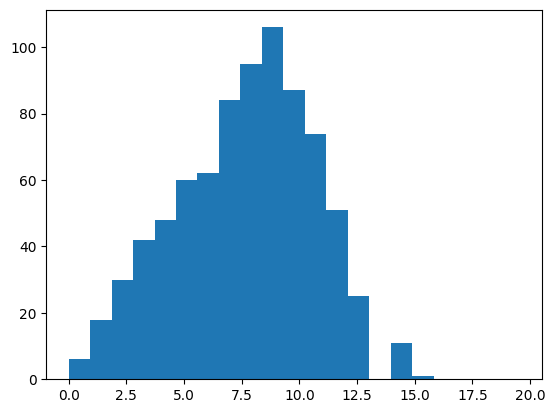

In [ ]:



cbins = np.arange(0, perioY + Lb * perioY / np.sqrt(Nc), Lb * perioY / np.sqrt(Nc))
nbins = len(cbins)

# Bin vertices into categories based on distance from chiral cell center
vCategories = np.zeros(Nv, dtype=int)
for v_id in range(Nv):
    dist = np.sqrt(v_x_rel[v_id]**2 + v_y_rel[v_id]**2)
    for bin_id in range(nbins - 1):
        if cbins[bin_id] <= dist < cbins[bin_id + 1]:
            vCategories[v_id] = bin_id

hist_vCategories, _ = np.histogram(vCategories, bins=cbins)
print('Vertex category histogram:', hist_vCategories)

plt.figure()
plt.hist(vCategories, bins=cbins)

In [ ]:
v_fr = np.zeros(nbins)
v_fphi = np.zeros(nbins)
count = np.zeros(nbins)
for v_id in range(Nv):
    f_r = (v_fx[v_id] * v_x_rel[v_id] + v_fy[v_id] * v_y_rel[v_id]) / np.sqrt(v_x_rel[v_id]**2 + v_y_rel[v_id]**2)
    f_phi = (v_fx[v_id] * (-v_y_rel[v_id]) + v_fy[v_id] * v_x_rel[v_id]) / np.sqrt(v_x_rel[v_id]**2 + v_y_rel[v_id]**2)
    v_fr[vCategories[v_id]] += f_r
    v_fphi[vCategories[v_id]] += f_phi
    count[vCategories[v_id]] += 1


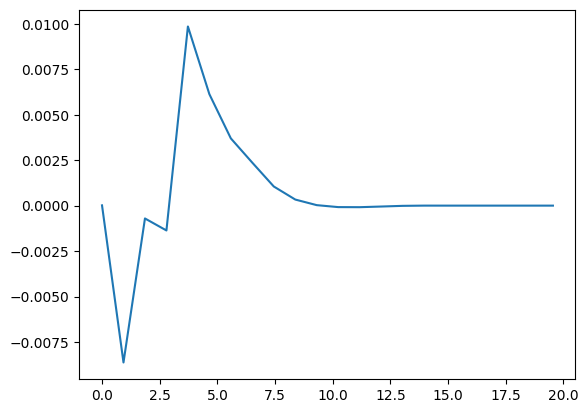

In [ ]:
plt.figure()
plt.plot(cbins,v_fr)


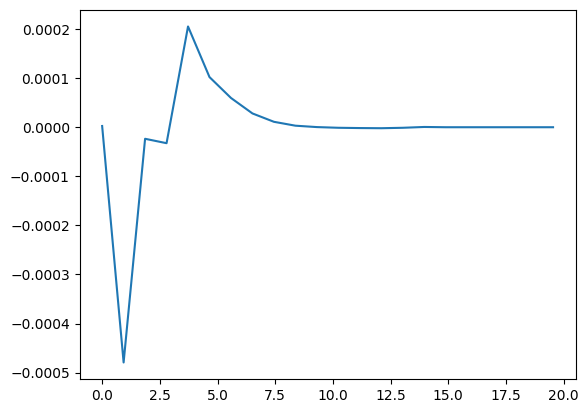

In [ ]:
plt.figure()
plt.plot(cbins,np.divide(v_fr, count, out=np.zeros_like(v_fr), where=count != 0))

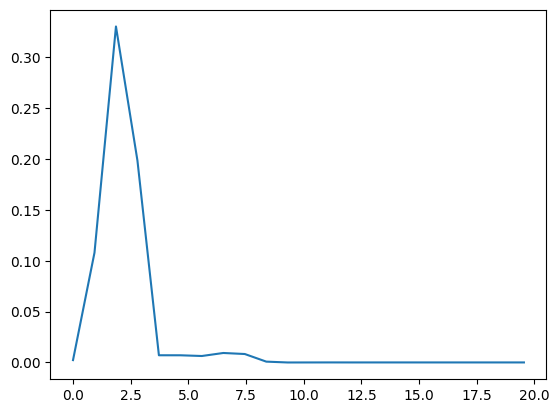

In [ ]:
plt.figure()
plt.plot(cbins,v_fphi)

In [ ]:




v_fr = np.divide(v_fr, count, out=np.zeros_like(v_fr), where=count != 0)
v_fphi = np.divide(v_fphi, count, out=np.zeros_like(v_fphi), where=count != 0)
